In [1]:
import numpy as np
import matplotlib.pyplot as plt
from readData import lire_monitor_sofa

#### Test A // Apply a force at the end of the beam

Cantilever beam with a fixed base and a free end where we apply a small force F_small

In [2]:
def analytic_solution(F, EI, s, L):
    """
    F: force appliquée au bout de la tige
    EI: raideur en flexion (E: module de Young, I: moment d'inertie)
    s : abscisse curviligne
    """
    # On effectue un developpement limité d'ordre 2 pour le calcul de x

    return s - (F**2/(2.0*EI**2)) * (L**2*s**3 / 3. - L*s**4/4. - s**5/120.0), -F * (0.5*L*s**2 - s**3 / 6.) / EI

In [2]:
# Paramètres
L = 1.
r = 0.01
E = 1e6
I = np.pi*r**4 / 4.
EI = E*I
F_small = 1e-3

The static solution of a beam clamped at one end s = 0
and subjected to the downward force F at the free end s = L.

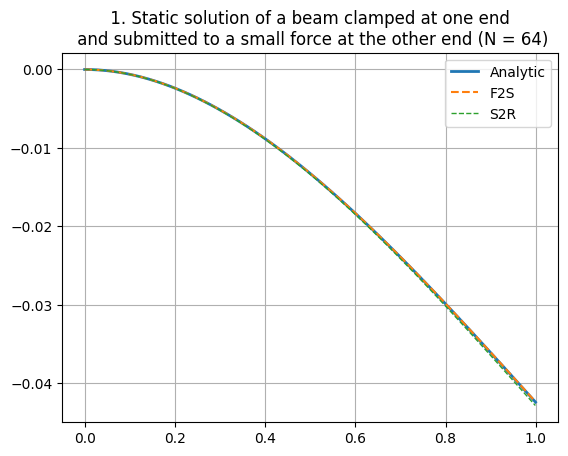

In [4]:
# with a number of section equal to 64
N = 64

s = np.linspace(0, L, N+1)
x_exA, y_exA = analytic_solution(F_small, EI, s, L)

data_f2s = lire_monitor_sofa("f2s_test_A_profile64.txt",beam_length=L, nb_section=N)
x_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 0]
y_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 1]


data_s2r = lire_monitor_sofa("s2r_test_A_profile64.txt",beam_length=L, nb_section=N)
x_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 0]
y_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 1]

plt.plot(x_exA, y_exA, linewidth=2, label="Analytic")
plt.plot(x_f2s, y_f2s, '--', linewidth=1.5, label="F2S")
plt.plot(x_s2r, y_s2r, '--', linewidth=1, label="S2R")
plt.legend()
plt.grid(True)
plt.title(f" 1. Static solution of a beam clamped at one end \n and submitted to a small force at the other end (N = {N})")
plt.show()

In [5]:
N_list = [2, 4, 8, 16, 32, 64, 128, 256, 512] # nb of section

err_list_f2s = []
err_list_s2r = []

for N in N_list:
    s = np.linspace(0, L, N+1)
    x_exact, y_exact = analytic_solution(F_small, EI, s, L)
    data_f2s = lire_monitor_sofa(f"f2s_test_A_profile{N}.txt", beam_length=L, nb_section=N)
    data_s2r = lire_monitor_sofa(f"s2r_test_A_profile{N}.txt", beam_length=L, nb_section=N)

    x_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 0]
    y_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 1]

    err_f2s = np.max(np.sqrt((x_f2s - x_exact)**2 + (y_exact-y_f2s)**2)/N)
    err_list_f2s.append(err_f2s)

    x_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 0]
    y_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 1]

    err_s2r = np.max(np.sqrt((x_s2r - x_exact)**2 + (y_exact-y_s2r)**2)/N)
    err_list_s2r.append(err_s2r)

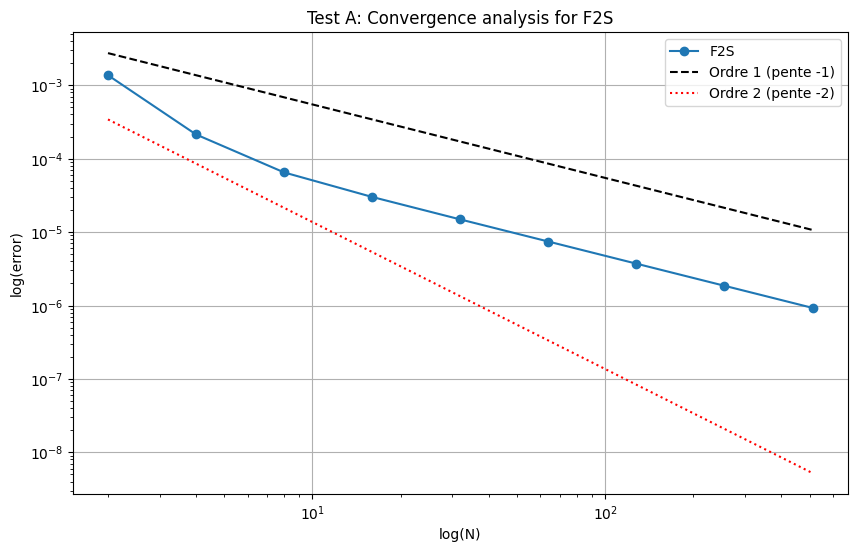

In [6]:
## pente d'ordre 1
N_start = N_list[0]
err_start = err_list_f2s[0]

pente_ordre_1 = 2*err_start * (N_start / np.array(N_list))**1
pente_ordre_2 = 0.25*err_start * (N_start / np.array(N_list))**2

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_list_f2s, 'o-', label="F2S")
plt.loglog(N_list, pente_ordre_1, '--', color='black', label="Ordre 1 (pente -1)")
plt.loglog(N_list, pente_ordre_2, ':', color='red', label="Ordre 2 (pente -2)")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title("Test A: Convergence analysis for F2S")
plt.show()

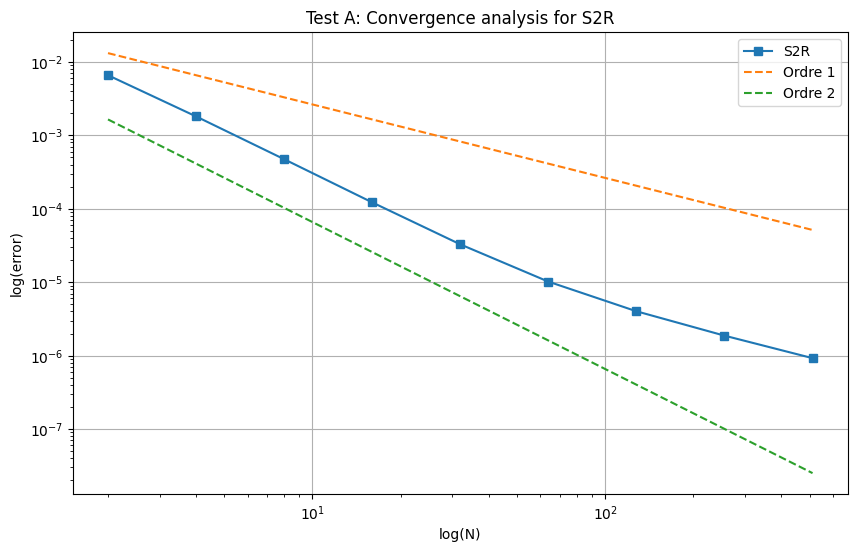

In [7]:
err_start_s2r = err_list_s2r[0]
pente_ordre_1 = 2*err_start_s2r * (N_list[0] / np.array(N_list))**1
pente_ordre_2 = 0.25*err_start_s2r * (N_list[0] / np.array(N_list))**2

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_list_s2r, 's-', label="S2R")
plt.loglog(N_list, pente_ordre_1, '--', label="Ordre 1")
plt.loglog(N_list, pente_ordre_2, '--', label="Ordre 2")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title("Test A: Convergence analysis for S2R")
plt.show()

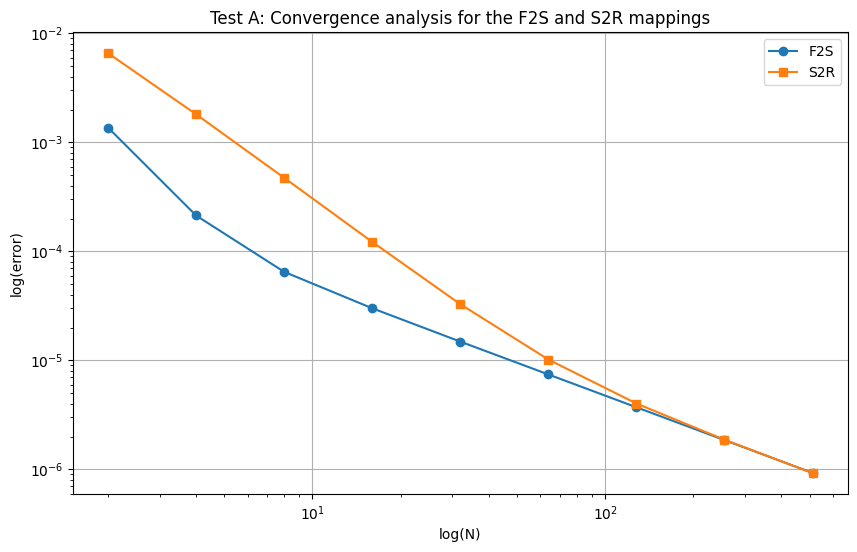

In [8]:
# plot de l'erreur dans la meme figure

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_list_f2s, 'o-', label="F2S")
plt.loglog(N_list, err_list_s2r, 's-', label="S2R")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title('Test A: Convergence analysis for the F2S and S2R mappings')
plt.show()

### Test B // Apply a torque at the end of the beam

Cantilever beam with a fixed base and free end where we apply a torque M0

In [9]:
def analytic_solution2(M0, EI, s):
    """
    M0: moment appliqué au bout de la tige
    EI: raideur en flexion (E: module de Young, I: moment d'inertie)
    s : abscisse curviligne
    """
    R = EI/M0

    return R * np.sin(s/R), R * (1 - np.cos(s/R))

In [10]:
#Parameter (same beam parameters as in test A)
M0 = np.pi * EI / L 
print(M0)

0.024674011002723397


Static solution for this problem

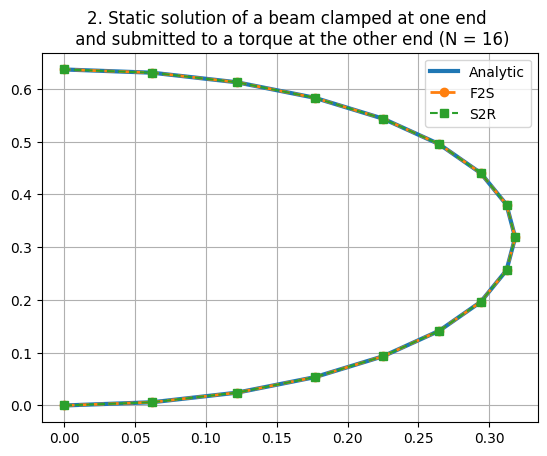

In [11]:
# with a number of section equal to 16
N = 16

s = np.linspace(0, L, N+1)
x_exB, y_exB = analytic_solution2(M0, EI, s)

data_f2sB = lire_monitor_sofa("f2s_test_B_profile16.txt",beam_length=L, nb_section=N)
x_f2sB = data_f2sB[len(data_f2sB)-1]["pos"][:, 0]
y_f2sB = data_f2sB[len(data_f2sB)-1]["pos"][:, 1]


data_s2rB = lire_monitor_sofa("s2r_test_B_profile16.txt",beam_length=L, nb_section=N)
x_s2rB = data_s2rB[len(data_s2rB)-1]["pos"][:, 0]
y_s2rB = data_s2rB[len(data_s2rB)-1]["pos"][:, 1]

plt.plot(x_exB, y_exB, linewidth=3, label="Analytic")
plt.plot(x_f2sB, y_f2sB, 'o--', linewidth=2, label="F2S")
plt.plot(x_s2rB, y_s2rB, 's--', linewidth=1.5, label="S2R")
plt.legend()
plt.grid(True)
plt.title(f"2. Static solution of a beam clamped at one end \n and submitted to a torque at the other end (N = {N})")
plt.show()

In [12]:
N_list = [8, 16, 32, 64, 128] # nb of section

err_listB_f2s = []
err_listB_s2r = []

for N in N_list:
    s = np.linspace(0, L, N+1)
    x_exact, y_exact = analytic_solution2(M0, EI, s)
    data_f2s = lire_monitor_sofa(f"f2s_test_B_profile{N}.txt", beam_length=L, nb_section=N)
    data_s2r = lire_monitor_sofa(f"s2r_test_B_profile{N}.txt", beam_length=L, nb_section=N)

    x_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 0]
    y_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 1]

    err_f2s = np.max(np.sqrt((x_f2s - x_exact)**2 + (y_exact-y_f2s)**2)/N)
    err_listB_f2s.append(err_f2s)

    x_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 0]
    y_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 1]

    err_s2r = np.max(np.sqrt((x_s2r - x_exact)**2 + (y_exact-y_s2r)**2)/N)
    err_listB_s2r.append(err_s2r)

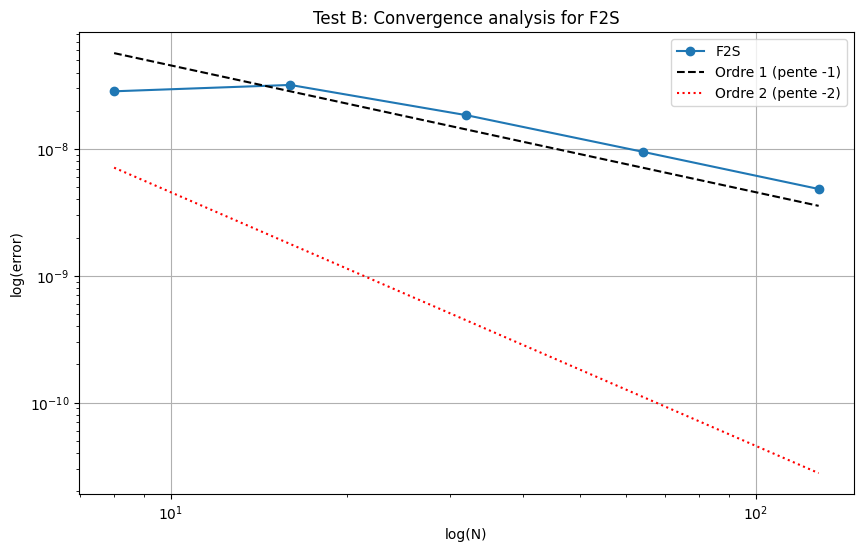

In [13]:
## pente d'ordre 1
N_start = N_list[0]
err_start = err_listB_f2s[0]

pente_ordre_1 = 2*err_start * (N_start / np.array(N_list))**1
pente_ordre_2 = 0.25*err_start * (N_start / np.array(N_list))**2

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_listB_f2s, 'o-', label="F2S")
plt.loglog(N_list, pente_ordre_1, '--', color='black', label="Ordre 1 (pente -1)")
plt.loglog(N_list, pente_ordre_2, ':', color='red', label="Ordre 2 (pente -2)")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title("Test B: Convergence analysis for F2S")
plt.show()

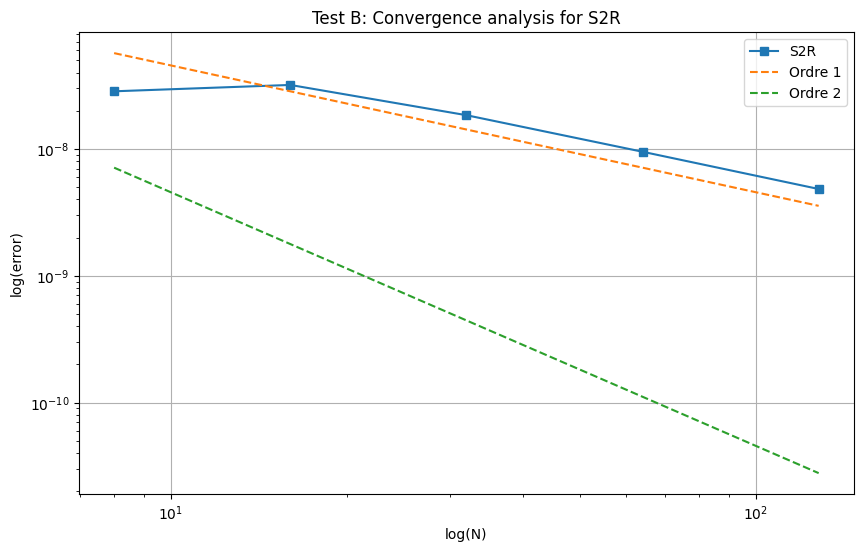

In [14]:
err_start_s2r = err_listB_s2r[0]
pente_ordre_1 = 2*err_start_s2r * (N_list[0] / np.array(N_list))**1
pente_ordre_2 = 0.25*err_start_s2r * (N_list[0] / np.array(N_list))**2

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_listB_s2r, 's-', label="S2R")
plt.loglog(N_list, pente_ordre_1, '--', label="Ordre 1")
plt.loglog(N_list, pente_ordre_2, '--', label="Ordre 2")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title("Test B: Convergence analysis for S2R")
plt.show()

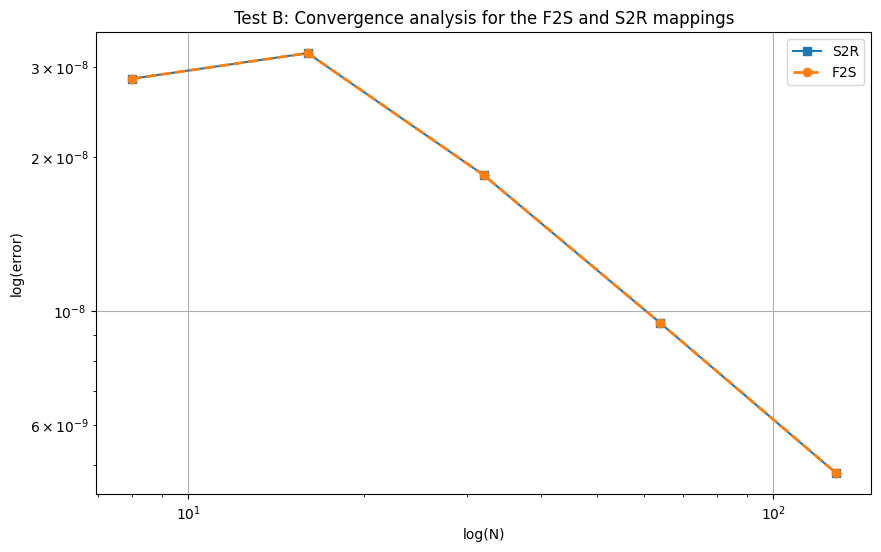

In [15]:
# plot de l'erreur dans la meme figure

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_listB_s2r, 's-', label="S2R")
plt.loglog(N_list, err_listB_f2s, 'o--', linewidth=2, label="F2S")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title('Test B: Convergence analysis for the F2S and S2R mappings')
plt.show()

### Test C -- Petite déformation + Force répartie // Acier

In [16]:
######## C pour suivre la logique (les fichiers restent avec le D :) )
# Acier
L = 1.
r = 0.01
E = 200e9
I = np.pi*r**4 / 4.
EI = E*I

rho = 7800 # Steel

A = np.pi * r**2

beam_mass = rho * A * L
grav = -9.81

wE = rho * A * grav # charge par unité de longueur

print(f"force per length= {wE} N")

force per length= -24.03883866673838 N


In [17]:
def analytic_solution3(f, EI, s, L):
    """
    f: force le long de la tige
    EI: raideur en flexion (E: module de Young, I: moment d'inertie)
    s : abscisse curviligne
    L : Longueur de la tige
    """
    # On effectue un developpement limité d'ordre 2 pour le calcul de x

    return s - (f**2 / (2.0*EI**2))*(L**4 * s**3 / 12.0 - L**3 * s**4/8 + L**2 * s**5 /12.0 - L*s**6/36.0 + s**7/252), f*((L*s)**2/4. -  (L*s**3)/6. + s**4/24.)/EI

Static solution for this problem

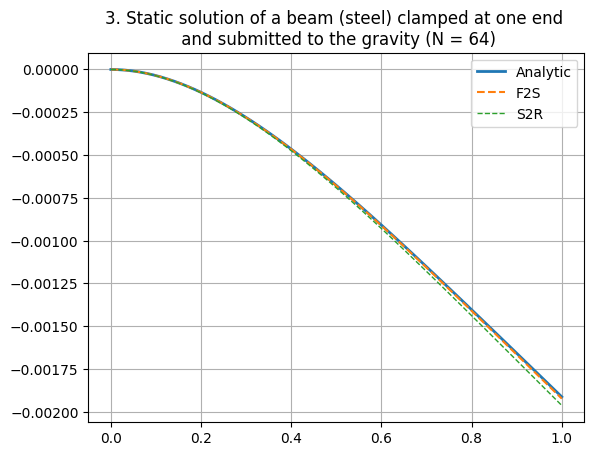

In [18]:
# with a number of section equal to 16
N = 64

s = np.linspace(0, L, N+1)
x_exactD, y_exactD = analytic_solution3(wE, EI, s, L)

data_f2sD = lire_monitor_sofa("f2s_test_D_profile64.txt",beam_length=L, nb_section=N)
x_f2sD = data_f2sD[len(data_f2sD)-1]["pos"][:, 0]
y_f2sD = data_f2sD[len(data_f2sD)-1]["pos"][:, 1]


data_s2rD = lire_monitor_sofa("s2r_test_D_profile64.txt",beam_length=L, nb_section=N)
x_s2rD = data_s2rD[len(data_s2rD)-1]["pos"][:, 0]
y_s2rD = data_s2rD[len(data_s2rD)-1]["pos"][:, 1]

plt.plot(x_exactD, y_exactD, linewidth=2, label="Analytic")
plt.plot(x_f2sD, y_f2sD, '--', linewidth=1.5, label="F2S")
plt.plot(x_s2rD, y_s2rD, '--', linewidth=1, label="S2R")
plt.legend()
plt.grid(True)
plt.title(f"3. Static solution of a beam (steel) clamped at one end \n and submitted to the gravity (N = {N})")
plt.show()

In [19]:
N_list = [8, 16, 32, 64, 128] # nb of section

err_listD_f2s = []
err_listD_s2r = []

for N in N_list:
    s = np.linspace(0, L, N+1)
    x_exact, y_exact = analytic_solution3(wE, EI, s, L)
    data_f2s = lire_monitor_sofa(f"f2s_test_D_profile{N}.txt", beam_length=L, nb_section=N)
    data_s2r = lire_monitor_sofa(f"s2r_test_D_profile{N}.txt", beam_length=L, nb_section=N)

    x_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 0]
    y_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 1]

    err_f2s = np.max(np.sqrt((x_f2s - x_exact)**2 + (y_exact-y_f2s)**2)/N)
    err_listD_f2s.append(err_f2s)

    x_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 0]
    y_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 1]

    err_s2r = np.max(np.sqrt((x_s2r - x_exact)**2 + (y_exact-y_s2r)**2)/N)
    err_listD_s2r.append(err_s2r)

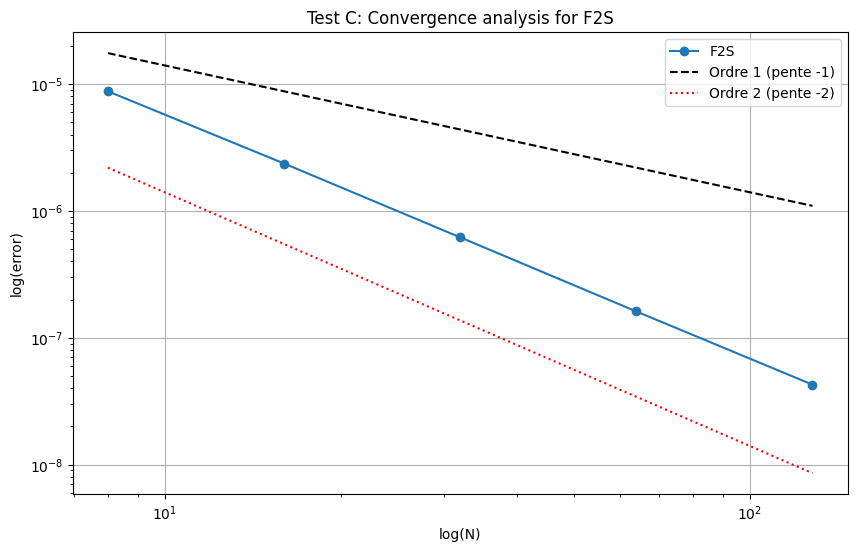

In [20]:
## pente d'ordre 1
N_start = N_list[0]
err_start = err_listD_f2s[0]

pente_ordre_1 = 2*err_start * (N_start / np.array(N_list))**1
pente_ordre_2 = 0.25*err_start * (N_start / np.array(N_list))**2

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_listD_f2s, 'o-', label="F2S")
plt.loglog(N_list, pente_ordre_1, '--', color='black', label="Ordre 1 (pente -1)")
plt.loglog(N_list, pente_ordre_2, ':', color='red', label="Ordre 2 (pente -2)")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title("Test C: Convergence analysis for F2S")
plt.show()

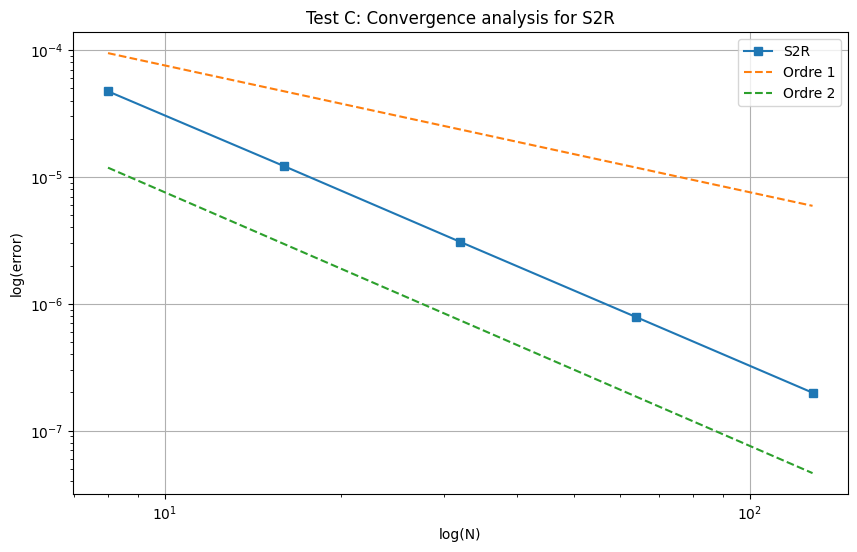

In [21]:
err_start_s2r = err_listD_s2r[0]
pente_ordre_1 = 2*err_start_s2r * (N_list[0] / np.array(N_list))**1
pente_ordre_2 = 0.25*err_start_s2r * (N_list[0] / np.array(N_list))**2

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_listD_s2r, 's-', label="S2R")
plt.loglog(N_list, pente_ordre_1, '--', label="Ordre 1")
plt.loglog(N_list, pente_ordre_2, '--', label="Ordre 2")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title("Test C: Convergence analysis for S2R")
plt.show()

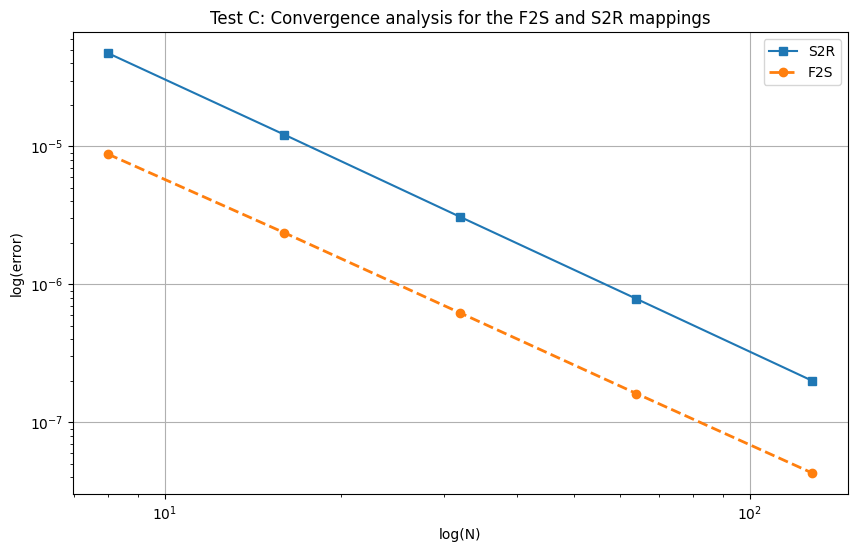

In [22]:
# plot de l'erreur dans la meme figure

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_listD_s2r, 's-', label="S2R")
plt.loglog(N_list, err_listD_f2s, 'o--', linewidth=2, label="F2S")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title('Test C: Convergence analysis for the F2S and S2R mappings')
plt.show()

### Test D -- Grande deformation + solution de reference // Caoutchouc

In [3]:
from scipy.integrate import solve_bvp

In [24]:
def solve_theta(alpha, L, n_init=100):
    """
    Resout l'equation theta''(u) + alpha*u*cos(theta) = 0 // obtenu en posant u = L-s
    Conditions : θ'(0) = 0 (moment nul au bout)
             θ(L) = 0 (encastrement)
    """
 
    def solve_ode(u, y):
        theta = y[0]
        dtheta = y[1]

        d2theta = -alpha*u*np.cos(theta)

        return np.vstack((dtheta, d2theta))
 
    def bc(ya, yb):
        return np.array([ya[1], yb[0]])
 
    u = np.linspace(0., L, n_init)
    y0 = np.zeros((2, u.size))

    #Estimation initiale
    y0[0] = (alpha / 6) * (u**3 - L**3)
    y0[1] = (alpha / 2) * u**2

    sol = solve_bvp(solve_ode, bc, u, y0, tol=1e-10, max_nodes=100000)
    if not sol.success:
        raise RuntimeError("BVP solver failed: " + sol.message)
    return sol


In [25]:
#Parameters
youngModulus: float = 10e6 # Caoutchouc
rho: float = 1200 # Caoutchouc

A: float = np.pi * r**2
I: float = np.pi * r**4 / 4
EI: float = youngModulus * I
beam_mass: float = rho * A * L

w = rho * A * grav # charge par unité de longueur

alpha = w / EI
print(f"alpha= {alpha}")



def reference_solution(alpha, s, L):
    sol_theta = solve_theta(alpha, L)

    u_vals  = L - s
    theta   = sol_theta.sol(u_vals)[0]


    ds = s[1] - s[0]
    theta_moy = (theta[:-1] + theta[1:]) / 2
    x = np.zeros_like(s);  y = np.zeros_like(s)
    x[1:] = np.cumsum(np.cos(theta_moy) * ds)
    y[1:] = np.cumsum(np.sin(theta_moy) * ds)

    return x, y

alpha= -47.087999999999994


Static solution for this problem

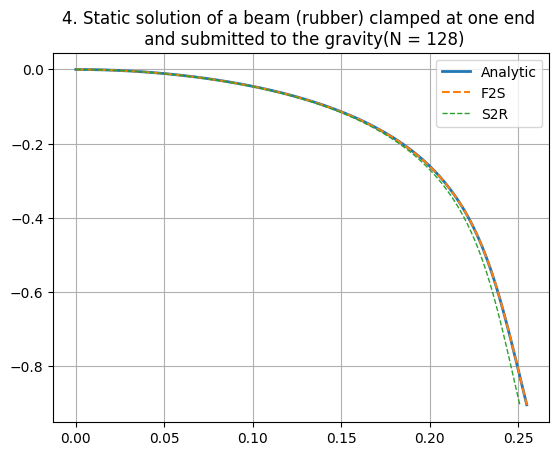

In [26]:
# with a number of section equal to 16
N = 128

s = np.linspace(0, L, N+1)
x_exactE, y_exactE =  reference_solution(alpha, s, L)

data_f2sE = lire_monitor_sofa("f2s_test_E_profile128.txt",beam_length=L, nb_section=N)
x_f2sE = data_f2sE[len(data_f2sE)-1]["pos"][:, 0]
y_f2sE = data_f2sE[len(data_f2sE)-1]["pos"][:, 1]


data_s2rE= lire_monitor_sofa("s2r_test_E_profile128.txt",beam_length=L, nb_section=N)
x_s2rE = data_s2rE[len(data_s2rE)-1]["pos"][:, 0]
y_s2rE = data_s2rE[len(data_s2rE)-1]["pos"][:, 1]

plt.plot(x_exactE, y_exactE, linewidth=2, label="Analytic")
plt.plot(x_f2sE, y_f2sE, '--', linewidth=1.5, label="F2S")
plt.plot(x_s2rE, y_s2rE, '--', linewidth=1, label="S2R")
plt.legend()
plt.grid(True)
plt.title(f"4. Static solution of a beam (rubber) clamped at one end \n and submitted to the gravity(N = {N})")
plt.show()

In [27]:
N_list = [8, 16, 32, 64, 128, 256, 512] # nb of section

err_listE_f2s = []
err_listE_s2r = []

for N in N_list:
    s = np.linspace(0, L, N+1)
    x_ref, y_ref = reference_solution(alpha, s, L)
    data_f2s = lire_monitor_sofa(f"f2s_test_E_profile{N}.txt", beam_length=L, nb_section=N)
    data_s2r = lire_monitor_sofa(f"s2r_test_E_profile{N}.txt", beam_length=L, nb_section=N)

    x_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 0]
    y_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 1]

    err_f2s = np.max(np.sqrt((x_f2s - x_ref)**2 + (y_ref-y_f2s)**2)/N)
    err_listE_f2s.append(err_f2s)

    x_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 0]
    y_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 1]

    err_s2r = np.max(np.sqrt((x_s2r - x_ref)**2 + (y_ref-y_s2r)**2)/N)
    err_listE_s2r.append(err_s2r)

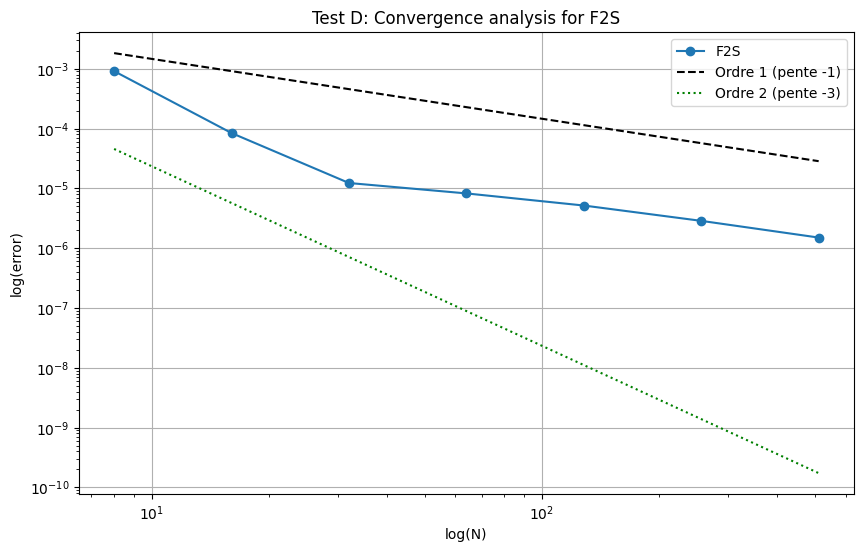

In [28]:
## pente d'ordre 1
N_start = N_list[0]
err_start = err_listE_f2s[0]

pente_ordre_1 = 2*err_start * (N_start / np.array(N_list))**1
pente_ordre_2 = 0.25*err_start * (N_start / np.array(N_list))**2
pente_ordre_3 = 0.05*err_start * (N_start / np.array(N_list))**3

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_listE_f2s, 'o-', label="F2S")
plt.loglog(N_list, pente_ordre_1, '--', color='black', label="Ordre 1 (pente -1)")
# plt.loglog(N_list, pente_ordre_2, ':', color='red', label="Ordre 2 (pente -2)")
plt.loglog(N_list, pente_ordre_3, ':', color='green', label="Ordre 2 (pente -3)")

plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title("Test D: Convergence analysis for F2S")
plt.show()

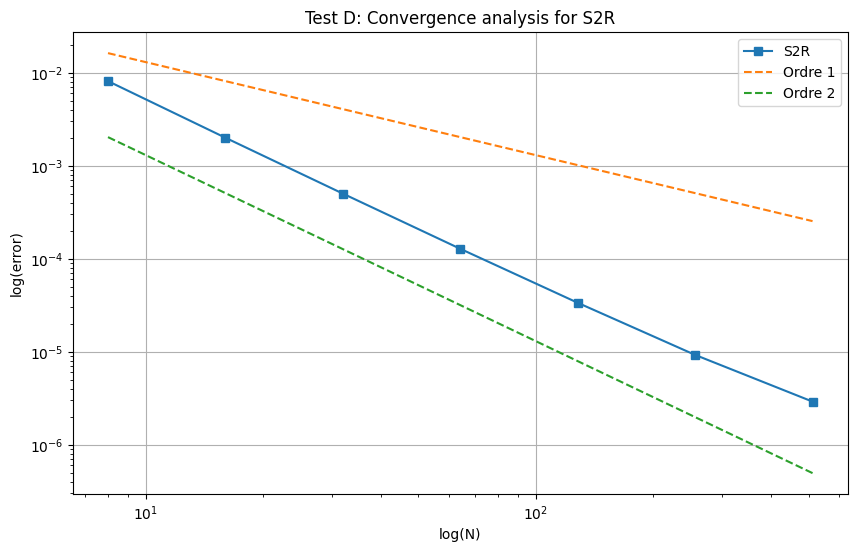

In [29]:
err_start_s2r = err_listE_s2r[0]
pente_ordre_1 = 2*err_start_s2r * (N_list[0] / np.array(N_list))**1
pente_ordre_2 = 0.25*err_start_s2r * (N_list[0] / np.array(N_list))**2

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_listE_s2r, 's-', label="S2R")
plt.loglog(N_list, pente_ordre_1, '--', label="Ordre 1")
plt.loglog(N_list, pente_ordre_2, '--', label="Ordre 2")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title("Test D: Convergence analysis for S2R")
plt.show()

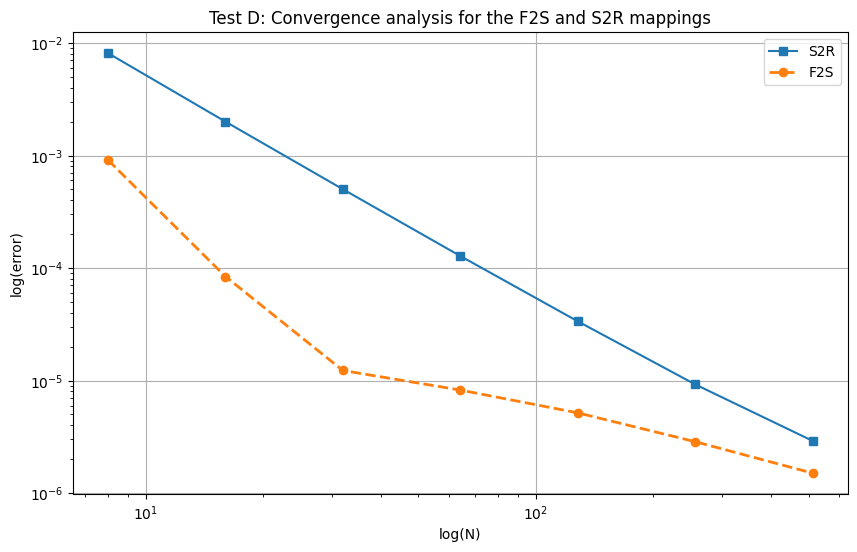

In [30]:
# plot de l'erreur dans la meme figure

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_listE_s2r, 's-', label="S2R")
plt.loglog(N_list, err_listE_f2s, 'o--', linewidth=2, label="F2S")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title('Test D: Convergence analysis for the F2S and S2R mappings')
plt.show()

### Test E: Appliquer une force (gravite) / et moment sur le bout de la tige

In [4]:
# On obtient le même ode à résoudre pour trouver theta que dans le cas précédent, seule la cdt sur u=0 qui est différent (égal à M0/EI au lieu de 0)
## !! Modification en se basant sur la méthode de "Load Stepping" pour eviter que solve_bvp converge vers une solution non physque
## on augmente la charge étape par étape

def solve_theta2(alpha_final, M0_final, EI, L, n_init=100, n_steps=10):
    """
    Resout l'equation theta''(u) + alpha*u*cos(theta) = 0 // obtenu en posant u = L-s
    Conditions : θ'(0) = -M0/EI (moment nul au bout)
             θ(L) = 0 (encastrement)
    """

    u = np.linspace(0., L, n_init)
    y_guess = np.zeros((2, u.size))   # on commence avec une tige horizontale 
 
    for step in range(1, n_steps+1):
        frac = step / n_steps
        alpha_step = alpha_final * frac
        M0_step = M0_final * frac

        def solve_ode(u, y):
            theta = y[0]
            dtheta = y[1]

            d2theta = -alpha_step*u*np.cos(theta)

            return np.vstack((dtheta, d2theta))
    
        def bc(ya, yb):
            return np.array([ya[1] + M0_step/EI, yb[0]])
 

    sol = solve_bvp(solve_ode, bc, u, y_guess, tol=1e-10, max_nodes=100000)
    if not sol.success:
        raise RuntimeError("BVP solver failed: " + sol.message)
    return sol


In [5]:
#Parameters
youngModulus: float = 10e6 # Caoutchouc
rho: float = 1200 # Caoutchouc

A: float = np.pi * r**2
I: float = np.pi * r**4 / 4
EI: float = youngModulus * I
beam_mass: float = rho * A * L
grav = -9.81

wF = rho * A * grav # charge par unité de longueur

alphaF = wF / EI 
print(f"alpha= {alphaF}")


M0 = 2*np.pi * youngModulus * I / L 
print(M0)

def reference_solution2(alpha, s, L):
    sol_theta = solve_theta2(alpha, M0, EI, L)

    u_vals  = L - s
    theta   = sol_theta.sol(u_vals)[0]


    ds = s[1] - s[0]
    theta_moy = (theta[:-1] + theta[1:]) / 2
    x = np.zeros_like(s);  y = np.zeros_like(s)
    x[1:] = np.cumsum(np.cos(theta_moy) * ds)
    y[1:] = np.cumsum(np.sin(theta_moy) * ds)

    return x, y

alpha= -47.087999999999994
0.4934802200544679


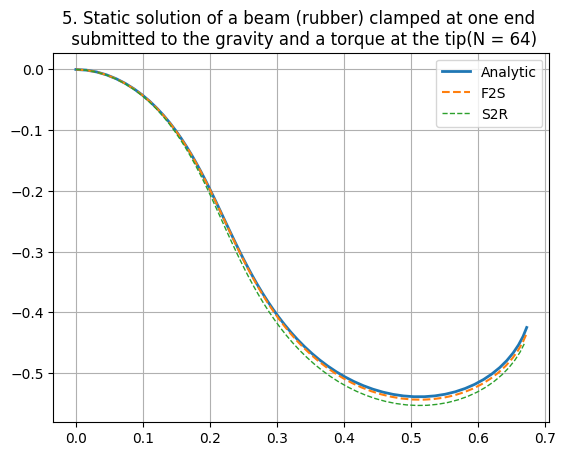

In [7]:
# with a number of section equal to 16
N = 64

s = np.linspace(0, L, N+1)
x_exactF, y_exactF =  reference_solution2(alphaF, s, L)


data_f2sF = lire_monitor_sofa("f2s_test_F_profile64.txt",beam_length=L, nb_section=N)
x_f2sF = data_f2sF[len(data_f2sF)-1]["pos"][:, 0]
y_f2sF = data_f2sF[len(data_f2sF)-1]["pos"][:, 1]


data_s2rF= lire_monitor_sofa("s2r_test_F_profile64.txt",beam_length=L, nb_section=N)
x_s2rF = data_s2rF[len(data_s2rF)-1]["pos"][:, 0]
y_s2rF = data_s2rF[len(data_s2rF)-1]["pos"][:, 1]

plt.plot(x_exactF, y_exactF, linewidth=2, label="Analytic")
plt.plot(x_f2sF, y_f2sF, '--', linewidth=1.5, label="F2S")
plt.plot(x_s2rF, y_s2rF, '--', linewidth=1, label="S2R")
plt.legend()
plt.grid(True)
plt.title(f"5. Static solution of a beam (rubber) clamped at one end \n submitted to the gravity and a torque at the tip(N = {N})")
plt.show()

In [8]:
N_list = [8, 16, 32, 64, 128] # nb of section

err_listF_f2s = []
err_listF_s2r = []

for N in N_list:
    s = np.linspace(0, L, N+1)
    x_ref, y_ref = reference_solution2(alphaF, s, L)
    data_f2s = lire_monitor_sofa(f"f2s_test_F_profile{N}.txt", beam_length=L, nb_section=N)
    data_s2r = lire_monitor_sofa(f"s2r_test_F_profile{N}.txt", beam_length=L, nb_section=N)

    x_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 0]
    y_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 1]

    err_f2s = np.max(np.sqrt((x_f2s - x_ref)**2 + (y_ref-y_f2s)**2)/N)
    err_listF_f2s.append(err_f2s)

    x_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 0]
    y_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 1]

    err_s2r = np.max(np.sqrt((x_s2r - x_ref)**2 + (y_ref-y_s2r)**2)/N)
    err_listF_s2r.append(err_s2r)

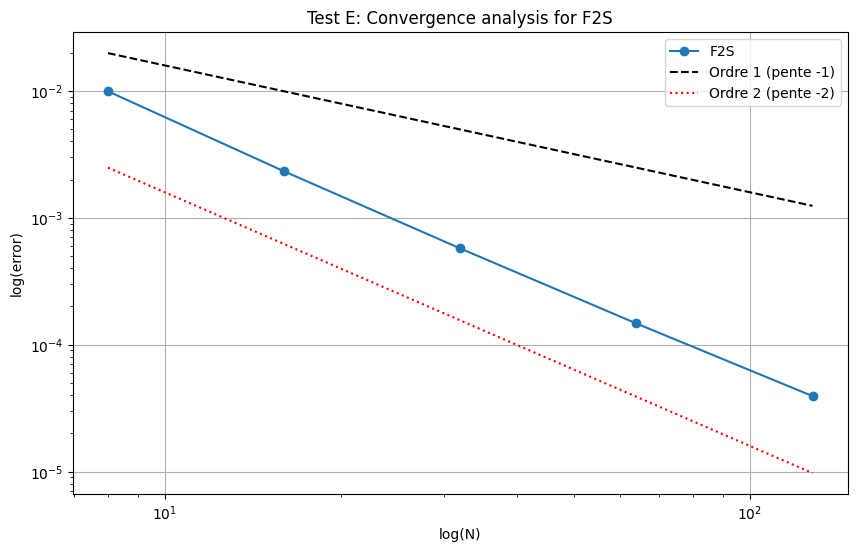

In [14]:
## pente d'ordre 1
N_start = N_list[0]
err_start = err_listF_f2s[0]

pente_ordre_1 = 2*err_start * (N_start / np.array(N_list))**1
pente_ordre_2 = 0.25*err_start * (N_start / np.array(N_list))**2
pente_ordre_3 = 0.05*err_start * (N_start / np.array(N_list))**3

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_listF_f2s, 'o-', label="F2S")
plt.loglog(N_list, pente_ordre_1, '--', color='black', label="Ordre 1 (pente -1)")
plt.loglog(N_list, pente_ordre_2, ':', color='red', label="Ordre 2 (pente -2)")
# plt.loglog(N_list, pente_ordre_3, ':', color='green', label="Ordre 2 (pente -3)")

plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title("Test E: Convergence analysis for F2S")
plt.show()

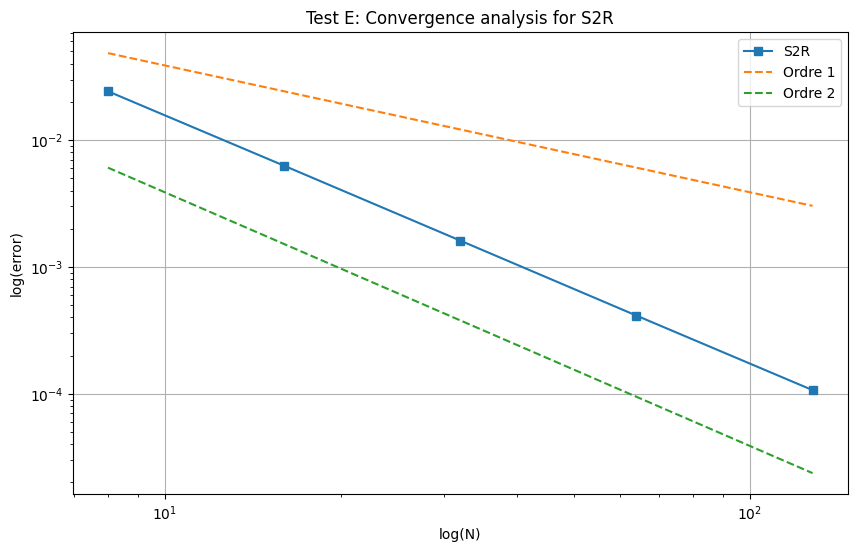

In [13]:
err_start_s2r = err_listF_s2r[0]
pente_ordre_1 = 2*err_start_s2r * (N_list[0] / np.array(N_list))**1
pente_ordre_2 = 0.25*err_start_s2r * (N_list[0] / np.array(N_list))**2

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_listF_s2r, 's-', label="S2R")
plt.loglog(N_list, pente_ordre_1, '--', label="Ordre 1")
plt.loglog(N_list, pente_ordre_2, '--', label="Ordre 2")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title("Test E: Convergence analysis for S2R")
plt.show()

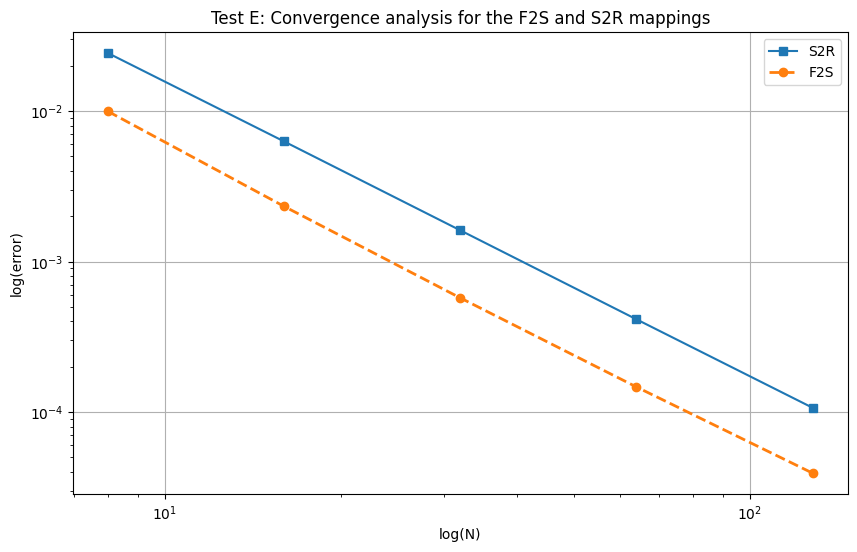

In [12]:
# plot de l'erreur dans la meme figure

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_listF_s2r, 's-', label="S2R")
plt.loglog(N_list, err_listF_f2s, 'o--', linewidth=2, label="F2S")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title('Test E: Convergence analysis for the F2S and S2R mappings')
plt.show()